In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from  matplotlib.ticker import FuncFormatter
%matplotlib inline

In [2]:
sns.set_theme(context="notebook", style="white", font_scale=2.5)

In [3]:
paths = [
        ("arabic", "results/ar_analysis_"),
        ("french", "results/fr_analysis_"),
        ("ngkolmpu", "results/ng_analysis_"),
        ("nuer", "results/nuer_analysis_"),
        ("russian", "results/rus_analysis_"),
        ("zenzontepec chatino", "results/zen_analysis_"),
         ]

In [4]:
def collate_data(paths):
    suffixes = ["_values_per_word.csv", "_values.csv", "_formatives.csv"]
    data = ([], [], [])
    for lg, path in paths:
        for suffix, dfs in zip(suffixes, data):
            df = pd.read_csv(path+suffix)
            df["Language"] = lg
            dfs.append(df)

    return tuple(pd.concat(dfs).reset_index() for dfs in data)

In [5]:
vals_w, vals, forms = collate_data(paths)

In [6]:
forms

,index,lexeme,tier,slot,formative,exponence,# of cells,dist_a,# values,cumulative cells,longest cumulation,% cells cumulative,% dimensions cumulation,Language
0,0,danā,segmental,0,j,3.m 3.p,4,ind.3.d.m.prs.act ind.3.prs.p.f.act ind.3.m.pr...,2,3.m 3.p,2,0.0,33.333333,arabic
1,1,danā,segmental,0,n,m/f.p,1,m/f.ind.1.prs.p.act,1,m/f.p,2,0.0,33.333333,arabic
2,2,danā,segmental,0,t,d.f 2 s.f,7,ind.3.s.prs.f.act 2.ind.m.s.prs.act ind.3.d.pr...,3,d.f s.f,2,0.0,33.333333,arabic
3,3,danā,segmental,1,adn,NaN,13,ind.3.s.prs.f.act 2.ind.m.s.prs.act ind.3.prs....,0,NaN,0,0.0,0.000000,arabic
4,4,danā,segmental,2,iː,s.2.f,1,2.ind.s.prs.f.act,1,s.2.f,3,0.0,50.000000,arabic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,145,ʔne⁰,segmental,3,e,prog,1,prog,1,NaN,0,0.0,0.000000,zenzontepec chatino
1112,146,ʔne⁰,segmental,4,ʔne,NaN,4,prog pot cpl hab,0,NaN,0,0.0,0.000000,zenzontepec chatino
1113,147,ʔne⁰,tone,0,⁰,hab,1,hab,1,NaN,0,0.0,0.000000,zenzontepec chatino
1114,148,ʔne⁰,tone,1,⁰,prog cpl hab,3,prog cpl hab,3,NaN,0,0.0,0.000000,zenzontepec chatino


In [7]:
plot_kwargs = dict(hue="Language", col="Language", height=8, aspect=1, discrete=True, stat='percent', common_norm=False)

# Formatives

We first look at the number of values expressed per formative.
- 0 corresponds stems
- 1 corresponds to simple exponence
- 2+ corresponds to syncretism

Of course, this is limited by the number of cells => For nuer we have only sg/pl so no more than 1 values can be expressed. It is always $n-1$ given $n$ cells.

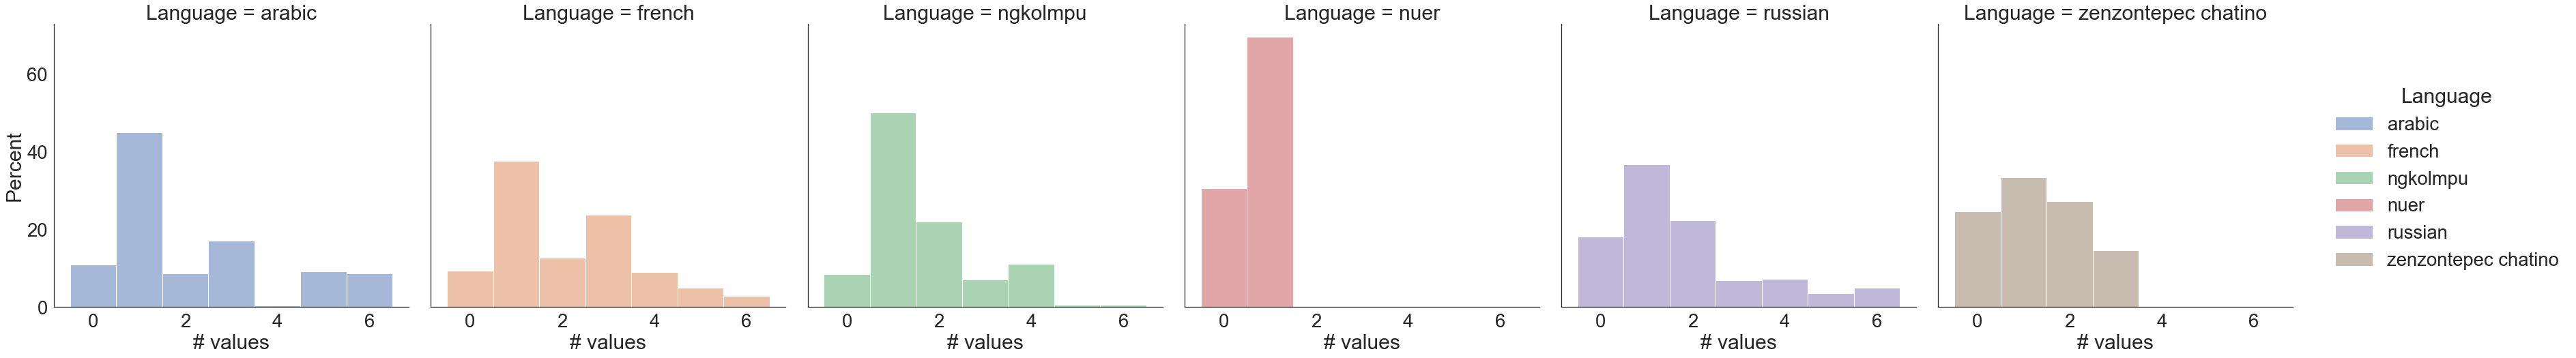

In [8]:

sns.displot(forms, x="# values", **plot_kwargs)
sns.despine()

Cardinality of values: corresponds to cumulative exponence.
- If 0: not cumumative
- above 0: cumulative

This one is artificially bounded by the fact that we made toy sets with few dimensions !

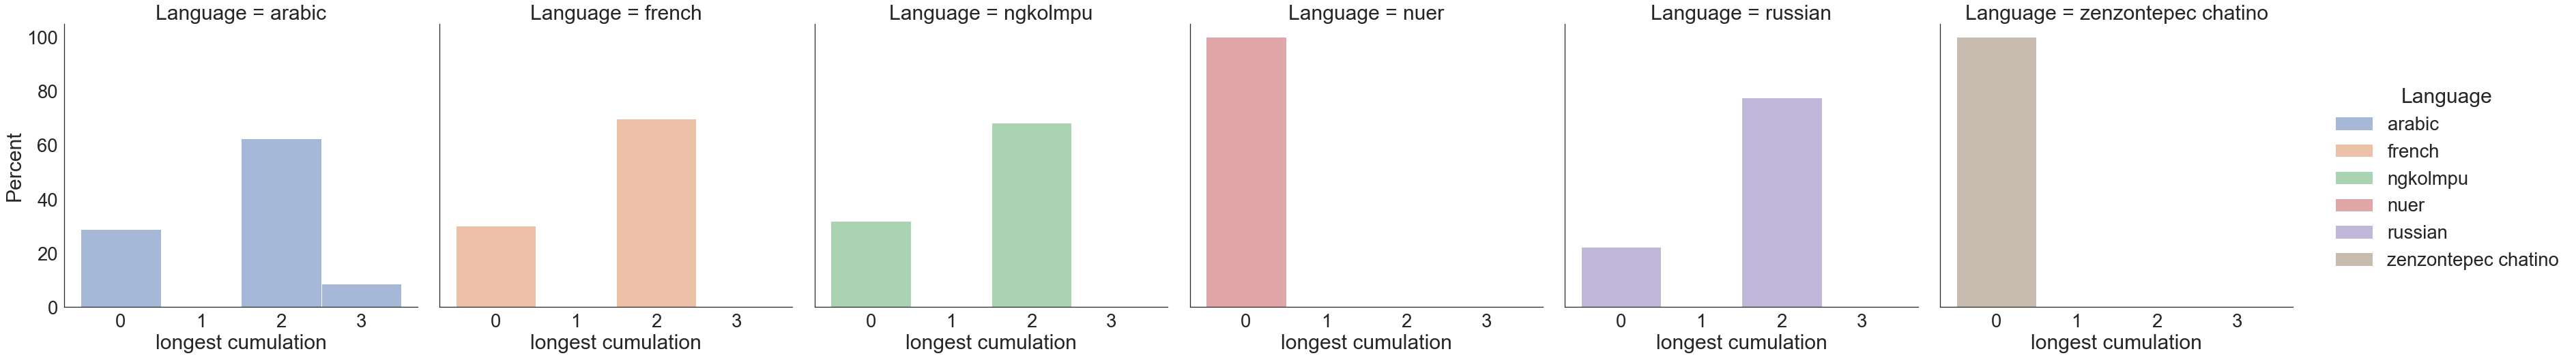

In [9]:

sns.displot(forms, x="longest cumulation", **plot_kwargs)
sns.despine()

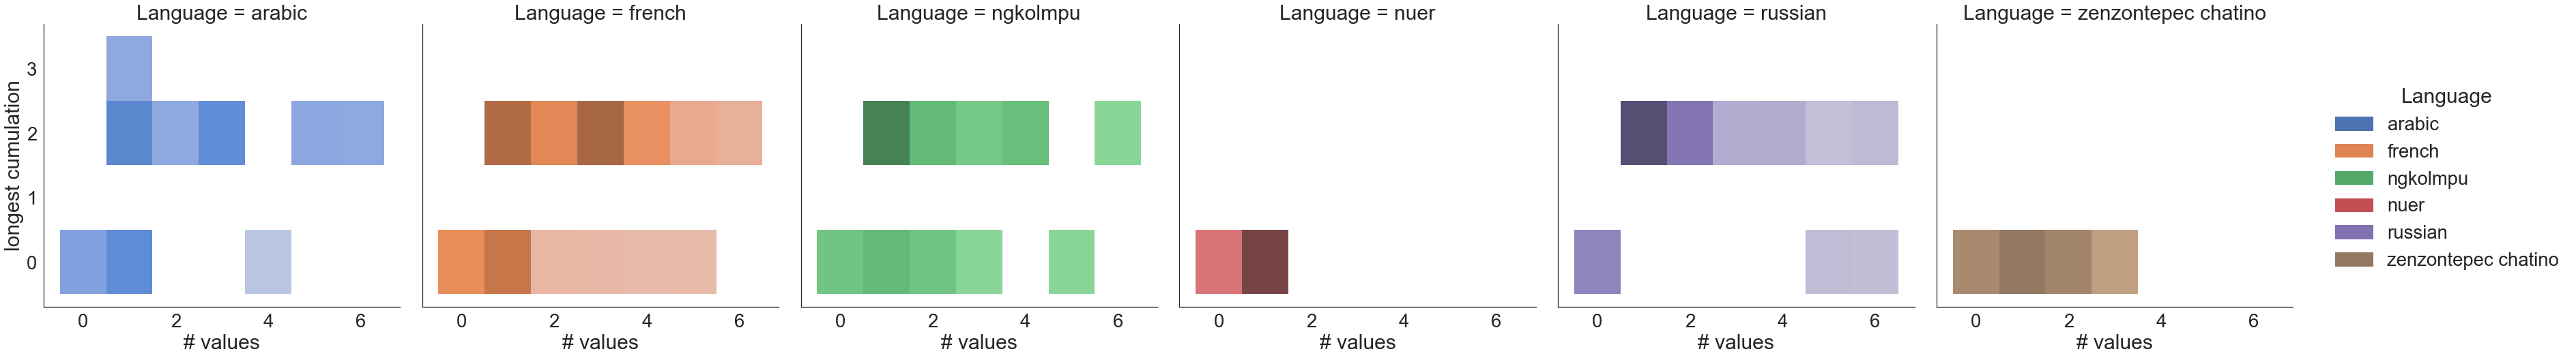

In [10]:

sns.displot(forms,  x="# values", y="longest cumulation", hue="Language", col="Language", height=8, aspect=1, discrete=True)
sns.despine()

## Values

Our measures are about unique exponence & allomorphy:

- Number of formatives: if 1, then this is unique exponence. If > 1: non-unique exponence.
- Number of allomorph sets: if 1, no allomorphy. The higher, the more allomorphy.
- Number of words: number of distint words (either overabundant or from different cells) expressing this value.
- % of allomorphs to words


In [11]:

import matplotlib.ticker as ticker

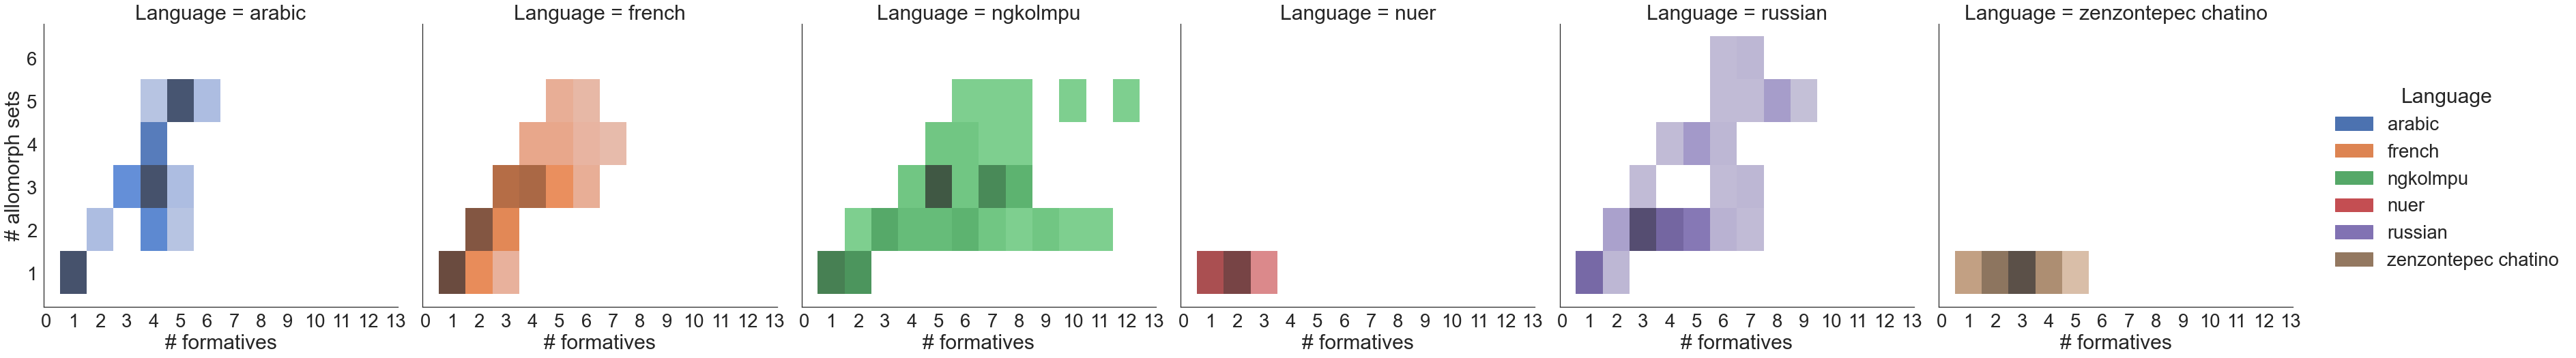

In [12]:

p = sns.displot(vals,  x="# formatives", y="# allomorph sets", **plot_kwargs)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(base=1))
#plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))
sns.despine()

In [13]:
vals

,index,lexeme,value,formative,formatives_by_word,# formatives,# allomorph sets,# words,% allomorph to words,Language
0,0,danā,1,<segmental_2_uː>,#<segmental_2_uː>#,1,1,2,50.000000,arabic
1,1,danā,2,<segmental_4_a> <segmental_2_iː> <segmental_0_...,#<segmental_0_t># #<segmental_0_t> <segmental_...,5,5,5,100.000000,arabic
2,2,danā,3,<segmental_2_uː> <segmental_4_a> <segmental_0_...,#<segmental_0_j># #<segmental_0_j> <segmental_...,4,4,6,66.666667,arabic
3,3,danā,d,<segmental_0_t> <segmental_2_uwaː> <segmental_...,#<segmental_2_uwaː> <segmental_3_n> <segmental...,4,2,3,66.666667,arabic
4,4,danā,f,<segmental_0_t> <segmental_4_a> <segmental_2_i...,#<segmental_0_t> <segmental_2_iː> <segmental_3...,4,3,5,60.000000,arabic
...,...,...,...,...,...,...,...,...,...,...
767,68,yu¹kų²ʔ,pot,<segmental_2_tʃ>,#<segmental_2_tʃ>#,1,1,1,100.000000,zenzontepec chatino
768,69,yu¹kų²ʔ,prog,<segmental_2_tʃ> <segmental_0_n> <tone_0_⁰> <s...,#<segmental_0_n> <segmental_1_te> <segmental_2...,4,1,1,100.000000,zenzontepec chatino
769,70,ʔne⁰,cpl,<tone_1_⁰> <segmental_2_k> <segmental_0_n> <se...,#<segmental_0_n> <segmental_2_k> <segmental_3_...,4,1,1,100.000000,zenzontepec chatino
770,71,ʔne⁰,hab,<tone_1_⁰> <tone_0_⁰> <segmental_2_al> <segmen...,#<segmental_1_t> <segmental_2_al> <segmental_3...,5,1,1,100.000000,zenzontepec chatino


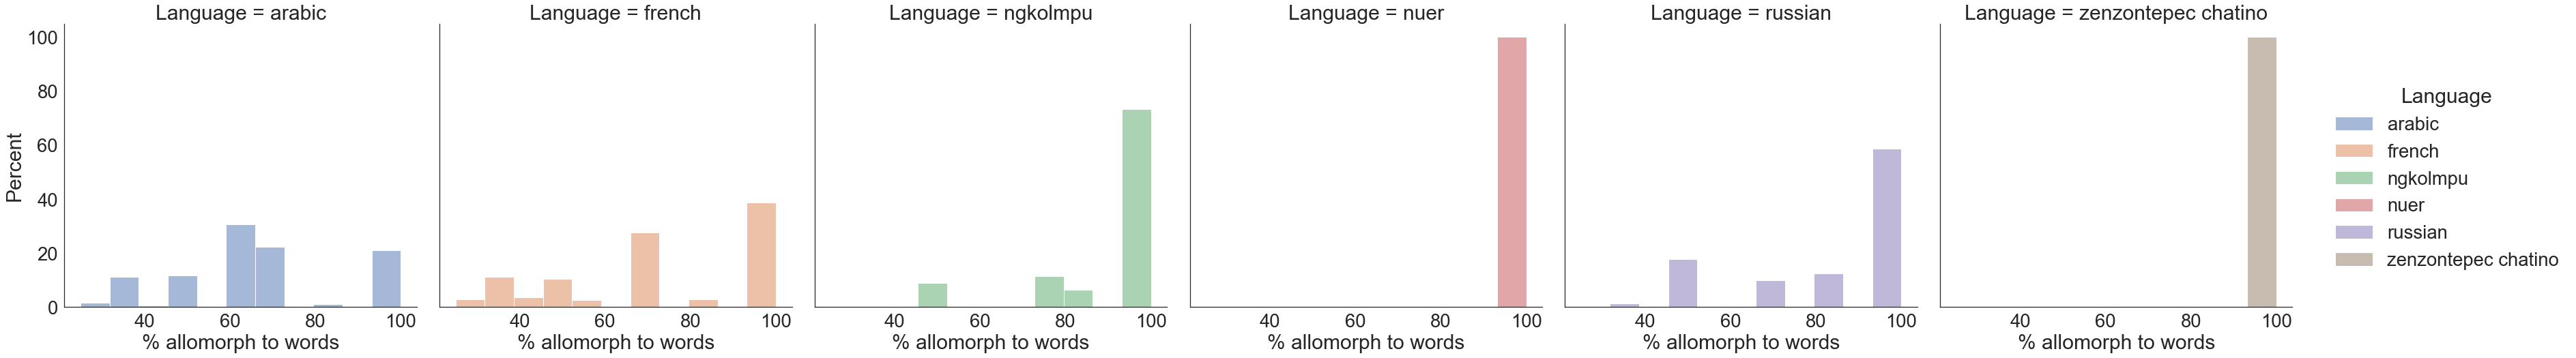

In [14]:
p = sns.displot(vals,  x="% allomorph to words", **dict(plot_kwargs, discrete=False))
sns.despine()

Verbose exponence:
- If a value in a given word is expressed by more than 1 formative, then it is verbose exponence !

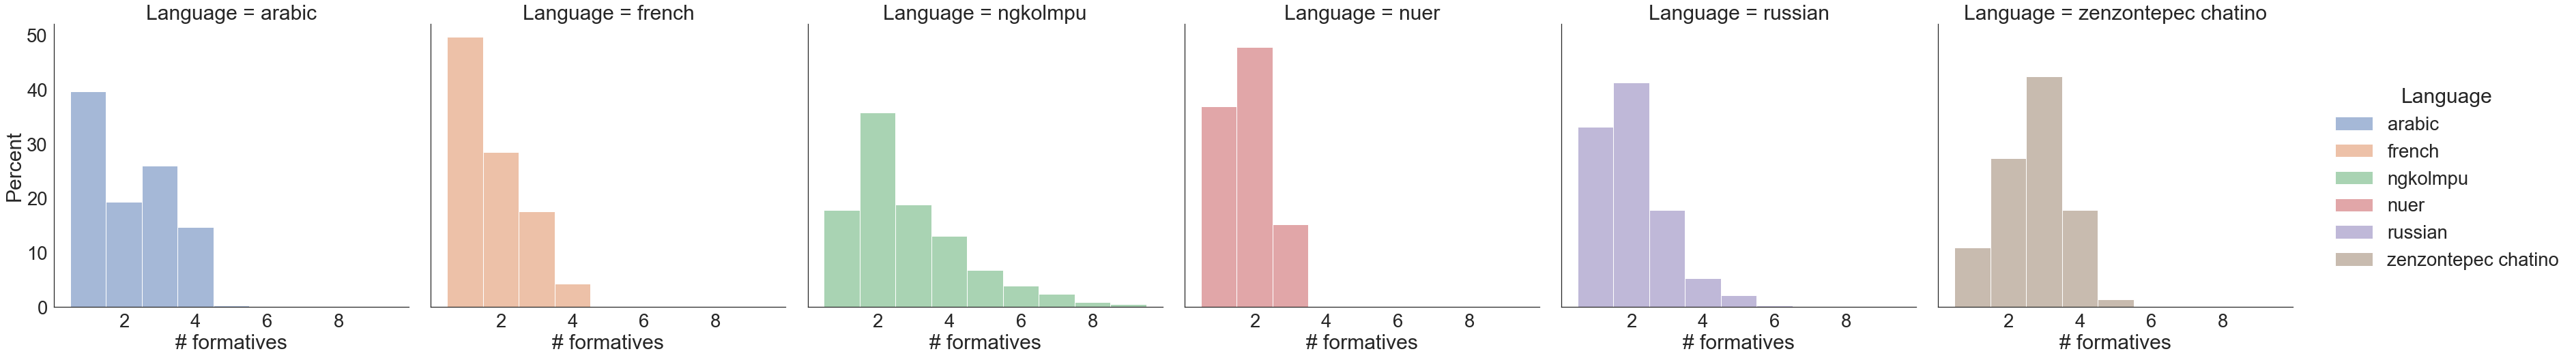

In [15]:

p = sns.displot(vals_w,  x="# formatives", **plot_kwargs)
sns.despine()